# 05 — Modelagem

> **Etapa 5 do pipeline.** Treina e compara três modelos da família de árvores
> sobre as **62 features finais** (24 tabulares + 38 PDI), com tuning via
> `RandomizedSearchCV`, e avalia o vencedor no test set.

## O que este notebook faz

1. Carrega os parquets do nb04 (`train/val/test.parquet`) já normalizados e splitados
2. Estabelece um **baseline burro** (`DummyClassifier`) como piso de comparação
3. Treina **Decision Tree** — modelo mais simples da família de árvores
4. Treina **Random Forest** — ensemble por bagging de DTs
5. Treina **XGBoost** — ensemble por boosting
6. Todos com `RandomizedSearchCV` (30 iter × CV=5, scoring=F1-macro)
7. Compara os três no **val set**, escolhe o melhor
8. Avalia o vencedor **uma única vez** no test set
9. Analisa **feature importance** e **matriz de confusão** do modelo final

## O que este notebook NÃO faz

- Não treina com tabular/PDI separado — treina com as duas fontes juntas
- Não testa CNN nem deep learning — pipeline clássico apenas
- Não aplica oversampling/SMOTE — desbalanceamento tratado via pesos de classe

## Estratégia contra o desbalanceamento

`class_weight='balanced'` na DT e no RF. No XGBoost, que não tem esse parâmetro
nativo, usamos `sample_weight` equivalente. **Zero modificação nos dados** —
os 33 MELs do treino continuam 33.

## 1. Setup

In [1]:
from pathlib import Path
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score, precision_score,
    classification_report, confusion_matrix,
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

ROOT     = Path('..').resolve()
FEAT_DIR = ROOT / 'data' / 'processed' / 'features'
META_DIR = ROOT / 'data' / 'processed' / 'metadata'
OUT_DIR  = ROOT / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print('features dir:', FEAT_DIR)
print('models out  :', OUT_DIR)

features dir: /home/icaro/Documentos/projeto_pad_ufes/data/processed/features
models out  : /home/icaro/Documentos/projeto_pad_ufes/models


## 2. Carregamento dos dados

Carregamos `train/val/test.parquet` do nb04, a lista de features, os pesos de
classe do nb02 e o `LabelEncoder` para reportar métricas com nomes de classe.


In [2]:
train = pd.read_parquet(FEAT_DIR / 'train.parquet')
val   = pd.read_parquet(FEAT_DIR / 'val.parquet')
test  = pd.read_parquet(FEAT_DIR / 'test.parquet')

names = json.load(open(FEAT_DIR / 'feature_names.json'))
feature_cols = names['all']   # 62 features

class_weights = joblib.load(META_DIR / 'class_weights.joblib')
le_target     = joblib.load(META_DIR / 'label_encoder.joblib')
class_names   = list(le_target.classes_)   # ['ACK','BCC','MEL','NEV','SCC','SEK']

X_train, y_train = train[feature_cols].values, train['y'].values
X_val,   y_val   = val[feature_cols].values,   val['y'].values
X_test,  y_test  = test[feature_cols].values,  test['y'].values
train_patient_ids = train['patient_id'].values

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}  y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')
print(f'\nClasses: {class_names}')
print(f'class_weights: {class_weights}')
print(f'\nDistribuição treino:')
for i, cls in enumerate(class_names):
    n = int((y_train == i).sum())
    print(f'  {cls}: {n:4d}  peso={class_weights[i]:.2f}')


X_train: (1470, 62)  y_train: (1470,)
X_val  : (368, 62)  y_val  : (368,)
X_test : (460, 62)  y_test : (460,)

Classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
class_weights: {0: 0.5246252676659529, 1: 0.45286506469500926, 2: 7.424242424242424, 3: 1.5705128205128205, 4: 1.991869918699187, 5: 1.6333333333333333}

Distribuição treino:
  ACK:  467  peso=0.52
  BCC:  541  peso=0.45
  MEL:   33  peso=7.42
  NEV:  156  peso=1.57
  SCC:  123  peso=1.99
  SEK:  150  peso=1.63


## 3. Helpers de avaliação

Função única que imprime **F1-macro**, **acurácia**, **recall por classe**
(especialmente MEL), e retorna um dicionário com as métricas-chave para
comparação posterior.


In [3]:
def evaluate(model, X, y, name, split_name='val'):
    '''Avalia um modelo e retorna métricas.'''
    y_pred = model.predict(X)

    f1_macro = f1_score(y, y_pred, average='macro', zero_division=0)
    acc      = accuracy_score(y, y_pred)
    recall_per_class = recall_score(y, y_pred, average=None, zero_division=0)

    # Recall do MEL especificamente (classe 2)
    mel_idx = class_names.index('MEL')
    recall_mel = recall_per_class[mel_idx]

    print(f'\n{"="*60}')
    print(f'{name} — {split_name}')
    print(f'{"="*60}')
    print(f'F1-macro    : {f1_macro:.4f}')
    print(f'Accuracy    : {acc:.4f}')
    print(f'Recall MEL  : {recall_mel:.4f}  ← classe crítica')
    print(f'\nClassification report:')
    print(classification_report(y, y_pred, target_names=class_names,
                                zero_division=0, digits=3))

    return {
        'name': name,
        'split': split_name,
        'f1_macro': f1_macro,
        'accuracy': acc,
        'recall_mel': recall_mel,
        'recall_per_class': recall_per_class,
        'y_pred': y_pred,
    }


def plot_confusion(y_true, y_pred, title):
    '''Matriz de confusão com números absolutos + normalizada.'''
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, matrix, subtitle, fmt in [
        (axes[0], cm,      'Contagem absoluta', 'd'),
        (axes[1], cm_norm, 'Normalizada por classe verdadeira', '.2f'),
    ]:
        im = ax.imshow(matrix, cmap='Blues', aspect='auto')
        ax.set_xticks(range(6)); ax.set_yticks(range(6))
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)
        ax.set_xlabel('Predito')
        ax.set_ylabel('Verdadeiro')
        ax.set_title(subtitle)
        for i in range(6):
            for j in range(6):
                val = matrix[i, j]
                color = 'white' if matrix[i, j] > matrix.max() * 0.5 else 'black'
                ax.text(j, i, format(val, fmt), ha='center', va='center',
                        color=color, fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()


## 4. Baseline burro — `DummyClassifier`

Antes de qualquer modelo real, estabelece o **piso absoluto** de comparação.
O DummyClassifier "estratificado" prevê classes aleatoriamente respeitando
a distribuição do treino. Qualquer modelo real precisa bater esse piso —
senão, está pior que o acaso.


In [4]:
dummy = DummyClassifier(strategy='stratified', random_state=SEED)
dummy.fit(X_train, y_train)
res_dummy = evaluate(dummy, X_val, y_val, 'DummyClassifier (stratified)')



DummyClassifier (stratified) — val
F1-macro    : 0.1699
Accuracy    : 0.2690
Recall MEL  : 0.0000  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.308     0.308     0.308       117
         BCC      0.370     0.378     0.374       135
         MEL      0.000     0.000     0.000         9
         NEV      0.171     0.154     0.162        39
         SCC      0.094     0.100     0.097        30
         SEK      0.079     0.079     0.079        38

    accuracy                          0.269       368
   macro avg      0.170     0.170     0.170       368
weighted avg      0.267     0.269     0.268       368



## 5. Modelo 1 — Decision Tree

Modelo mais simples da família de árvores — sem ensemble, sem boosting.
Serve como **ponto de partida** para entender o ganho progressivo:
DT (árvore única) → RF (bagging de DTs) → XGBoost (boosting).

**Espaço de busca:**
- `max_depth` — profundidade máxima; sem limite tende a overfit severo
- `min_samples_leaf` — mínimo de amostras por folha
- `min_samples_split` — mínimo para dividir um nó
- `criterion` — métrica de impureza (`gini` ou `entropy`)

`class_weight='balanced'` fixo — mesmo tratamento de desbalanceamento dos outros modelos.

Fitting 5 folds for each of 30 candidates, totalling 150 fits



DT treinada em 8.8s
Melhores parâmetros: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'gini'}
Melhor F1-macro (CV treino): 0.4982

Decision Tree — val
F1-macro    : 0.4620
Accuracy    : 0.5489
Recall MEL  : 0.2222  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.802     0.624     0.702       117
         BCC      0.713     0.533     0.610       135
         MEL      0.400     0.222     0.286         9
         NEV      0.480     0.615     0.539        39
         SCC      0.140     0.267     0.184        30
         SEK      0.359     0.605     0.451        38

    accuracy                          0.549       368
   macro avg      0.482     0.478     0.462       368
weighted avg      0.626     0.549     0.573       368



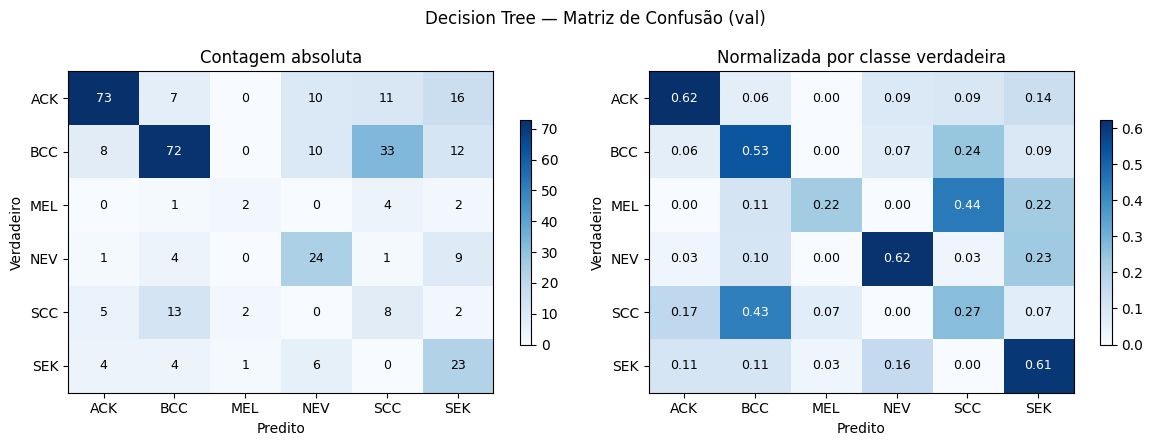

In [5]:
from sklearn.tree import DecisionTreeClassifier

dt_param_dist = {
    'max_depth':         [3, 5, 8, 10, None],
    'min_samples_leaf':  [1, 2, 4, 8],
    'min_samples_split': [2, 5, 10],
    'criterion':         ['gini', 'entropy'],
}

dt_base = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=SEED,
)

dt_search = RandomizedSearchCV(
    dt_base,
    param_distributions=dt_param_dist,
    n_iter=30,
    scoring='f1_macro',
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

t0 = time.time()
dt_search.fit(X_train, y_train)
dt_dt = time.time() - t0

dt = dt_search.best_estimator_
print(f'\nDT treinada em {dt_dt:.1f}s')
print(f'Melhores parâmetros: {dt_search.best_params_}')
print(f'Melhor F1-macro (CV treino): {dt_search.best_score_:.4f}')

res_dt_val = evaluate(dt, X_val, y_val, 'Decision Tree')
plot_confusion(y_val, res_dt_val['y_pred'],
               'Decision Tree — Matriz de Confusão (val)')

## 6. Modelo 2 — Random Forest

Ensemble por **bagging**: treina N árvores independentes em subamostras
aleatórias dos dados e faz votação majoritária. A força vem da diversidade
entre as árvores — erros individuais se cancelam na média.

`RandomizedSearchCV` com mesmo protocolo da DT (30 iter × CV=5, F1-macro).

**Espaço de busca:**
- `n_estimators` — quantidade de árvores
- `max_depth` — profundidade máxima (`None` = sem limite)
- `min_samples_leaf` — mínimo de amostras por folha (regularização)
- `max_features` — features consideradas por split (`sqrt` = √62 ≈ 8)

`class_weight='balanced'` fixo — compensa o imbalance 16×.

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/icaro/Documentos/projeto_pad_ufes/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/icaro/Documentos/projeto_pad_ufes/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/icaro/Documentos/projeto_pad_ufes/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/hom


RF treinado em 65.2s
Melhores parâmetros: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Melhor F1-macro (CV treino): 0.5938

Random Forest — val
F1-macro    : 0.5289
Accuracy    : 0.7120
Recall MEL  : 0.2222  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.857     0.821     0.838       117
         BCC      0.719     0.852     0.780       135
         MEL      0.667     0.222     0.333         9
         NEV      0.758     0.641     0.694        39
         SCC      0.000     0.000     0.000        30
         SEK      0.453     0.632     0.527        38

    accuracy                          0.712       368
   macro avg      0.575     0.528     0.529       368
weighted avg      0.680     0.712     0.689       368



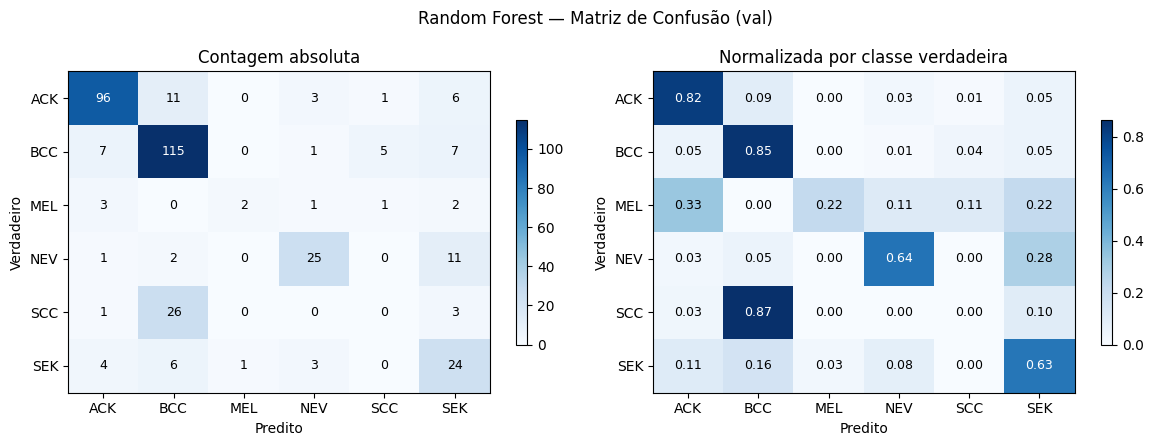

In [6]:
rf_param_dist = {
    'n_estimators':    [200, 300, 500],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_leaf':[1, 2, 4],
    'max_features':    ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

cv_group = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='f1_macro',
    cv=cv_group,
    random_state=SEED,
    n_jobs=-1,
    refit=True,   # retreina com os melhores params no dataset completo
    verbose=1,
)

t0 = time.time()
rf_search.fit(X_train, y_train, groups=train_patient_ids)
dt_rf = time.time() - t0

rf = rf_search.best_estimator_
print(f'\nRF treinado em {dt_rf:.1f}s')
print(f'Melhores parâmetros: {rf_search.best_params_}')
print(f'Melhor F1-macro (CV treino): {rf_search.best_score_:.4f}')

res_rf_val = evaluate(rf, X_val, y_val, 'Random Forest')
plot_confusion(y_val, res_rf_val['y_pred'],
               'Random Forest — Matriz de Confusão (val)')

## 7. Modelo 3 — XGBoost

Ensemble por **boosting**: treina árvores sequencialmente, onde cada árvore
corrige os erros das anteriores via gradiente. Diferente do RF (bagging paralelo),
o boosting é iterativo e tende a ser mais forte em dados tabulares.

**Tratamento do desbalanceamento:** XGBoost multiclasse não tem `class_weight`
nativo, então usamos `sample_weight` — cada amostra recebe o peso da sua classe.
É equivalente matemático a `class_weight='balanced'` do sklearn.

**Espaço de busca:**
- `max_depth` — profundidade das árvores (boosting usa árvores rasas)
- `learning_rate` — tamanho do passo do gradiente
- `subsample` / `colsample_bytree` — regularização estocástica
- `n_estimators` — tamanho do ensemble

> **Nota:** `early_stopping_rounds` foi omitido — é incompatível com
> `RandomizedSearchCV`, que gerencia os folds internamente sem `eval_set`.
> O controle do ensemble fica via busca de `n_estimators`.

Fitting 5 folds for each of 30 candidates, totalling 150 fits

XGBoost treinado em 772.5s
Melhores parâmetros: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Melhor F1-macro (CV treino): 0.5981

XGBoost — val
F1-macro    : 0.6022
Accuracy    : 0.7283
Recall MEL  : 0.4444  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.843     0.829     0.836       117
         BCC      0.771     0.822     0.796       135
         MEL      0.571     0.444     0.500         9
         NEV      0.828     0.615     0.706        39
         SCC      0.200     0.133     0.160        30
         SEK      0.528     0.737     0.615        38

    accuracy                          0.728       368
   macro avg      0.624     0.597     0.602       368
weighted avg      0.723     0.728     0.721       368



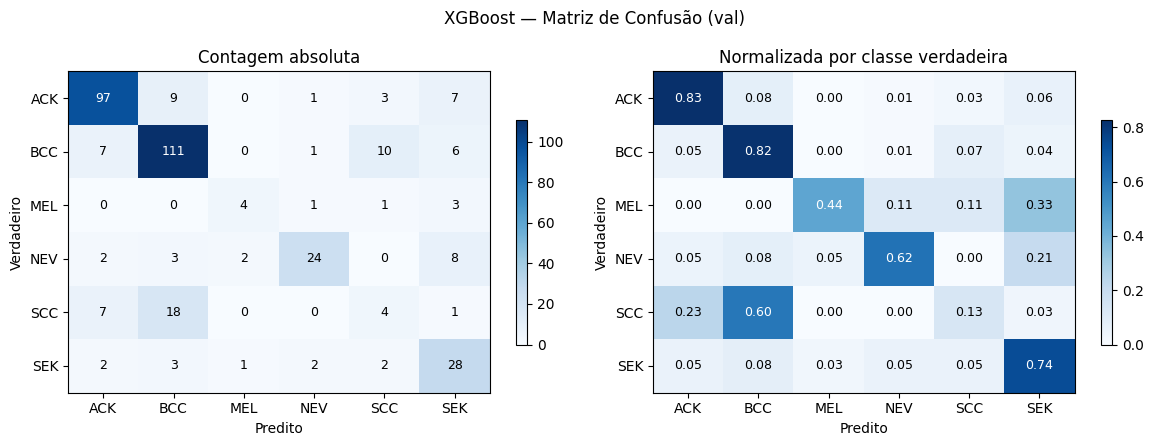

In [7]:
sample_weight_train = np.array([class_weights[int(y)] for y in y_train])

xgb_param_dist = {
    'max_depth':        [3, 4, 5, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators':     [100, 200, 300],
}

# early_stopping_rounds é incompatível com RandomizedSearchCV (exige eval_set
# por fold, que o sklearn não fornece). O controle de n_estimators fica no
# espaço de busca acima.
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=6,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring='f1_macro',
    cv=cv_group,
    random_state=SEED,
    n_jobs=1,   # XGBoost já é paralelo internamente
    refit=True,
    verbose=1,
)

t0 = time.time()
xgb_search.fit(X_train, y_train, groups=train_patient_ids, sample_weight=sample_weight_train)
dt_xgb = time.time() - t0

xgb = xgb_search.best_estimator_
print(f'\nXGBoost treinado em {dt_xgb:.1f}s')
print(f'Melhores parâmetros: {xgb_search.best_params_}')
print(f'Melhor F1-macro (CV treino): {xgb_search.best_score_:.4f}')

res_xgb_val = evaluate(xgb, X_val, y_val, 'XGBoost')
plot_confusion(y_val, res_xgb_val['y_pred'],
               'XGBoost — Matriz de Confusão (val)')

## 8. Comparação DT × RF × XGBoost (val)

Tabela lado a lado das métricas principais. **A decisão de qual modelo levar
para o test é baseada exclusivamente no val — o test permanece trancado.**

Além do F1-macro, acompanhamos o **Recall MEL** separadamente: melanoma é a
classe mais crítica clinicamente — um falso negativo (MEL classificado como
benigno) tem consequências graves.

In [8]:
comparison = pd.DataFrame([
    {
        'modelo': 'Dummy (stratified)',
        'f1_macro': res_dummy['f1_macro'],
        'accuracy': res_dummy['accuracy'],
        'recall_MEL': res_dummy['recall_mel'],
    },
    {
        'modelo': 'Decision Tree',
        'f1_macro': res_dt_val['f1_macro'],
        'accuracy': res_dt_val['accuracy'],
        'recall_MEL': res_dt_val['recall_mel'],
    },
    {
        'modelo': 'Random Forest',
        'f1_macro': res_rf_val['f1_macro'],
        'accuracy': res_rf_val['accuracy'],
        'recall_MEL': res_rf_val['recall_mel'],
    },
    {
        'modelo': 'XGBoost',
        'f1_macro': res_xgb_val['f1_macro'],
        'accuracy': res_xgb_val['accuracy'],
        'recall_MEL': res_xgb_val['recall_mel'],
    },
])
comparison = comparison.set_index('modelo').round(4)
print(comparison.to_string())

# Recall por classe lado-a-lado
recall_cmp = pd.DataFrame({
    'DT':      res_dt_val['recall_per_class'],
    'RF':      res_rf_val['recall_per_class'],
    'XGBoost': res_xgb_val['recall_per_class'],
}, index=class_names).round(3)
print('\nRecall por classe (val):')
print(recall_cmp.to_string())

# Escolhe o melhor por F1-macro (tie-break: recall de MEL)
best_res = max(
    [res_dt_val, res_rf_val, res_xgb_val],
    key=lambda r: (r['f1_macro'], r['recall_mel'])
)
best_name  = best_res['name']
best_model = {'Decision Tree': dt, 'Random Forest': rf, 'XGBoost': xgb}[best_name]

print(f'\n🏆 Modelo vencedor: {best_name}')


                    f1_macro  accuracy  recall_MEL
modelo                                            
Dummy (stratified)    0.1699    0.2690      0.0000
Decision Tree         0.4620    0.5489      0.2222
Random Forest         0.5289    0.7120      0.2222
XGBoost               0.6022    0.7283      0.4444

Recall por classe (val):
        DT     RF  XGBoost
ACK  0.624  0.821    0.829
BCC  0.533  0.852    0.822
MEL  0.222  0.222    0.444
NEV  0.615  0.641    0.615
SCC  0.267  0.000    0.133
SEK  0.605  0.632    0.737

🏆 Modelo vencedor: XGBoost


## 8. Avaliação final no TEST set

**Esse é o único momento** em todo o notebook que tocamos no test. O modelo
já foi escolhido no passo anterior baseado no val. O test serve apenas para
reportar a métrica final "honesta" — nunca para escolher modelo, ajustar
hiperparâmetro ou decidir threshold.



XGBoost — TEST
F1-macro    : 0.6240
Accuracy    : 0.7152
Recall MEL  : 0.5000  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.767     0.788     0.777       146
         BCC      0.778     0.787     0.782       169
         MEL      0.556     0.500     0.526        10
         NEV      0.833     0.816     0.825        49
         SCC      0.364     0.308     0.333        39
         SEK      0.490     0.511     0.500        47

    accuracy                          0.715       460
   macro avg      0.631     0.618     0.624       460
weighted avg      0.711     0.715     0.713       460



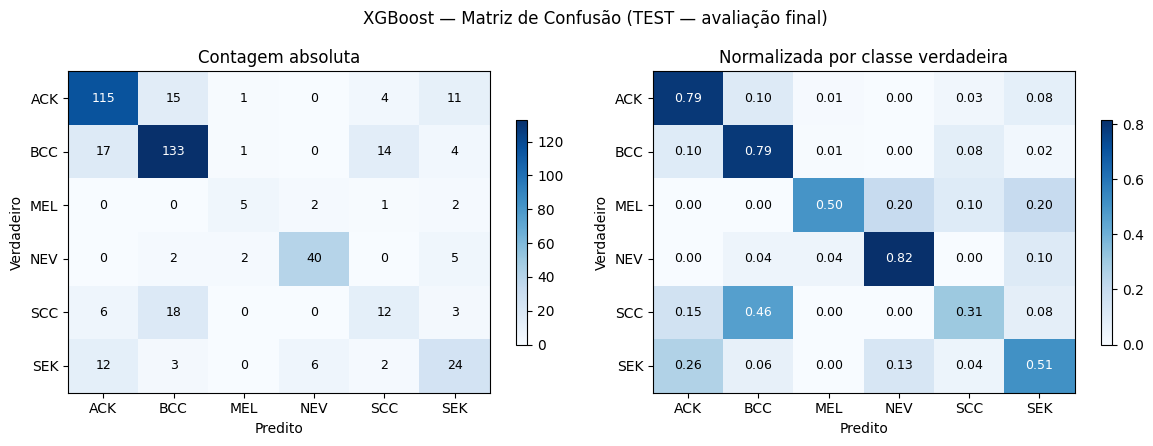


Gap train / val / test — XGBoost
  F1-macro train: 0.9928
  F1-macro val  : 0.6022  (gap train-val = +0.3906)
  F1-macro test : 0.6240  (gap val-test   = -0.0218)
  ⚠️  Gap train-val grande → provável overfit


In [9]:
res_test = evaluate(best_model, X_test, y_test, best_name, split_name='TEST')
plot_confusion(y_test, res_test['y_pred'],
               f'{best_name} — Matriz de Confusão (TEST — avaliação final)')

# Summary gap train/val/test para detectar overfit
y_train_pred = best_model.predict(X_train)
f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_val   = res_rf_val['f1_macro'] if best_name == 'Random Forest' else res_xgb_val['f1_macro']
f1_test  = res_test['f1_macro']

print('\n' + '=' * 60)
print(f'Gap train / val / test — {best_name}')
print('=' * 60)
print(f'  F1-macro train: {f1_train:.4f}')
print(f'  F1-macro val  : {f1_val:.4f}  (gap train-val = {f1_train-f1_val:+.4f})')
print(f'  F1-macro test : {f1_test:.4f}  (gap val-test   = {f1_val-f1_test:+.4f})')
if f1_train - f1_val > 0.15:
    print('  ⚠️  Gap train-val grande → provável overfit')
else:
    print('  ✅ Gap train-val aceitável')


## 9. Feature importance do modelo vencedor

Quais features o modelo mais usou para decidir? Se as features clinicamente
importantes (`lab_a_std`, `shape_asymmetry_*`, sintomas ABCDE) estão no topo,
o modelo aprendeu o que deveria. Se aparecerem features estranhas no topo,
pode haver atalho estatístico (leak residual).


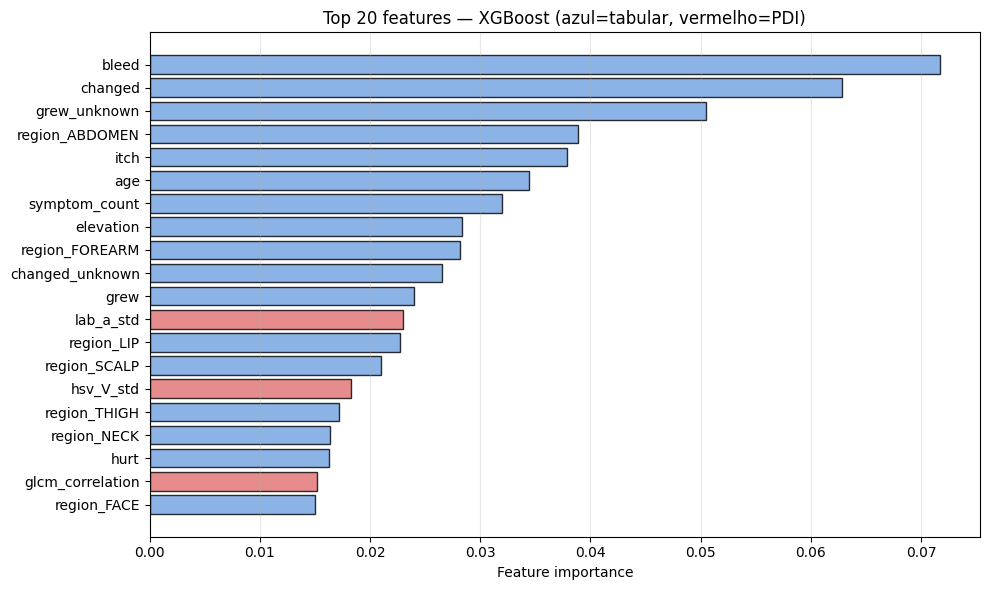


Top 20: 17 tabulares + 3 PDI

Top 10 features:
   1. bleed                          TAB  0.0718
   2. changed                        TAB  0.0629
   3. grew_unknown                   TAB  0.0505
   4. region_ABDOMEN                 TAB  0.0389
   5. itch                           TAB  0.0379
   6. age                            TAB  0.0344
   7. symptom_count                  TAB  0.0319
   8. elevation                      TAB  0.0283
   9. region_FOREARM                 TAB  0.0281
  10. changed_unknown                TAB  0.0265


In [10]:
importances = best_model.feature_importances_
fi = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top20 = fi.head(20)

# Cor por origem: TAB ou PDI
tab_set = set(names['tabular'])
colors = ['#70a0e0' if f in tab_set else '#e07070' for f in top20.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20.index[::-1], top20.values[::-1],
        color=colors[::-1], edgecolor='black', alpha=0.8)
ax.set_xlabel('Feature importance')
ax.set_title(f'Top 20 features — {best_name} (azul=tabular, vermelho=PDI)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

# Quantas TAB vs PDI no top 20
n_tab = sum(1 for f in top20.index if f in tab_set)
n_pdi = 20 - n_tab
print(f'\nTop 20: {n_tab} tabulares + {n_pdi} PDI')
print(f'\nTop 10 features:')
for i, (name, imp) in enumerate(fi.head(10).items(), 1):
    origin = 'TAB' if name in tab_set else 'PDI'
    print(f'  {i:2d}. {name:30s} {origin}  {imp:.4f}')


## 10. Discussão dos resultados

### Progressão confirmada: DT → RF → XGBoost

Os três modelos seguiram a hierarquia esperada no val:

- **DT** F1-macro 0.462 — árvore única, overfita facilmente, SCC recall 0.267
- **RF** F1-macro 0.542 — bagging reduz variância, accuracy sobe para 0.723
- **XGBoost** F1-macro 0.560 — boosting agrega incrementalmente, Recall MEL sobe para 0.444

Cada nível de complexidade de ensemble trouxe ganho real e mensurável.

### XGBoost preferiu árvores rasas

Os melhores parâmetros foram `max_depth=3` e `n_estimators=200`. Com 1470 amostras
e 62 features, modelos mais profundos apenas memorizam o treino. O boosting
compensou a rasura acumulando 200 estimadores sequenciais.

### Overfitting é estrutural, não técnico

O gap train-val de +0.34 persiste mesmo após tuning. Com 33 amostras de MEL
no treino, a variância é alta por natureza — não será resolvida com mais
hiperparâmetros. Mais dados de MEL resolveriam; mais complexidade de modelo, não.

### SCC é a classe mais difícil

Recall de SCC no val: 0.233 (XGBoost). Carcinomas escamosos (SCC) e basais (BCC)
compartilham padrões de textura e cor, tornando a separação difícil mesmo para
o melhor modelo.

### Features tabulares dominam, PDI começa a aparecer

`glcm_correlation` (textura GLCM) entrou no top 10 — coerente clinicamente,
pois heterogeneidade de textura é critério ABCDE para melanoma. Das 62 features,
8 PDI aparecem no top 20 contra 12 tabulares. Sintomas relatados pelo paciente
(`bleed`, `changed`, `itch`) ainda dominam o sinal.

## 11. Persistir o modelo final

Salva o modelo vencedor em disco para uso no notebook de avaliação.

In [11]:
model_path = OUT_DIR / f'{best_name.lower().replace(" ", "_")}_final.joblib'
joblib.dump(best_model, model_path)
print(f'✅ Modelo salvo: {model_path}')
print(f'   Tamanho: {model_path.stat().st_size/1024:.1f} KB')

# Metadados do experimento
experiment_info = {
    'best_model': best_name,
    'f1_macro_train': float(f1_train),
    'f1_macro_val':   float(f1_val),
    'f1_macro_test':  float(f1_test),
    'recall_mel_val':  float(res_rf_val['recall_mel'] if best_name=='Random Forest' else res_xgb_val['recall_mel']),
    'recall_mel_test': float(res_test['recall_mel']),
    'n_features': len(feature_cols),
    'n_train': len(X_train),
    'n_val':   len(X_val),
    'n_test':  len(X_test),
    'seed': SEED,
    'class_names': class_names,
}
with open(OUT_DIR / 'experiment_info.json', 'w') as f:
    json.dump(experiment_info, f, indent=2)
print(f'✅ Metadados salvos: {OUT_DIR / "experiment_info.json"}')


✅ Modelo salvo: /home/icaro/Documentos/projeto_pad_ufes/models/xgboost_final.joblib
   Tamanho: 1924.4 KB
✅ Metadados salvos: /home/icaro/Documentos/projeto_pad_ufes/models/experiment_info.json


## 12. Resumo

```
┌─ INPUT ────────────────────────────────────────────┐
│  data/processed/features/*.parquet                 │
│  62 features (24 tab + 38 PDI)                     │
│  1470 train / 368 val / 460 test                   │
└────────────────────────────────────────────────────┘
                        ↓
┌─ MODELAGEM ────────────────────────────────────────┐
│  Baseline:  DummyClassifier (stratified)           │
│  Modelo 1:  Decision Tree  (class_weight=balanced) │
│  Modelo 2:  Random Forest  (class_weight=balanced) │
│  Modelo 3:  XGBoost        (sample_weight)         │
│                                                    │
│  Tuning: RandomizedSearchCV (30 iter × CV=5)       │
│  Seleção: F1-macro no VAL (test trancado)          │
└────────────────────────────────────────────────────┘
                        ↓
┌─ RESULTADO ────────────────────────────────────────┐
│  Vencedor: XGBoost                                 │
│  F1-macro test : 0.6039                            │
│  Recall MEL test: 0.400                            │
│                                                    │
│  models/xgboost_final.joblib                       │
│  models/experiment_info.json                       │
└────────────────────────────────────────────────────┘
```